# Clasificacion de Genero Musical a partir de Features de Audio (Spotify) — Datos Reales

**Objetivo:** predecir el genero de una cancion (Classical, Jazz, Blues, Rock, Heavy-Metal, Hip-Hop, EDM, Pop, Reggae, Country) a partir de sus caracteristicas de audio, sin usar el nombre de la cancion ni del artista.

**Sobre los datos:** dataset real de Spotify (114,000 canciones, 114 generos, via Kaggle/HuggingFace -- `maharshipandya/spotify-tracks-dataset`). Se selecciono un subconjunto de 10 generos musicalmente distintos y reconocibles (de los 114 originales, muchos son sub-generos muy especificos o etiquetas de contexto como "children", "anime", "brazil" que no son generos musicales en el sentido tradicional).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## Carga de datos

In [2]:
total_data = pd.read_csv("../data/spotify_dataset_full.csv")
total_data = total_data.drop(columns=["Unnamed: 0"])
print(f"Filas: {total_data.shape[0]}, Generos distintos: {total_data['track_genre'].nunique()}")
total_data.head()


Filas: 114000, Generos distintos: 114


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## EDA y seleccion de generos

Con 114 generos, muchos son sub-generos muy especificos (`chicago-house`, `deep-house`, `detroit-techno` -- practicamente indistinguibles por audio) o etiquetas que no son generos musicales en el sentido tradicional (`children`, `anime`, `brazil`, `comedy`). Para un ejercicio de clasificacion claro e interpretable, se selecciono un subconjunto de 10 generos ampliamente reconocibles y musicalmente distintos entre si.

In [3]:
target_genres = ["classical", "jazz", "blues", "rock", "heavy-metal",
                  "hip-hop", "edm", "pop", "reggae", "country"]

df = total_data[total_data["track_genre"].isin(target_genres)].copy()
print(f"Filas en el subset: {df.shape[0]}")
df["track_genre"].value_counts()


Filas en el subset: 10000


track_genre
blues          1000
classical      1000
country        1000
edm            1000
heavy-metal    1000
hip-hop        1000
jazz           1000
pop            1000
reggae         1000
rock           1000
Name: count, dtype: int64

In [4]:
print(f"Duplicados (fila completa): {df.duplicated().sum()}")
print(f"Nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Duplicados (fila completa): 95
Nulos:
Series([], dtype: int64)


## Hallazgo importante: canciones etiquetadas en mas de un genero

A diferencia de lo que se podria asumir, cada `track_id` no es unico en el dataset -- la misma cancion puede aparecer varias veces, catalogada bajo generos distintos (por ejemplo, una cancion etiquetada tanto como `jazz` como `blues`).

In [5]:
dup_ids = df["track_id"].duplicated(keep=False)
print(f"Canciones (track_id) que aparecen en mas de un genero dentro de este subset: {df[dup_ids]['track_id'].nunique()}")

example = df[dup_ids].sort_values("track_id")[["track_id", "track_name", "track_genre"]].head(6)
example


Canciones (track_id) que aparecen en mas de un genero dentro de este subset: 683


,track_id,track_name,track_genre
8095,00970cTs7LnxWt0d5Qk08m,Sleigh Ride,blues
64246,00970cTs7LnxWt0d5Qk08m,Sleigh Ride,jazz
19042,014SIjoLDG1Ku19c5FlDYh,I Put A Spell On You,country
91138,014SIjoLDG1Ku19c5FlDYh,I Put A Spell On You,rock
16747,03B8ZXUmuDpf59j5PIMFHq,"Ma che vi fece... Sperai vicino, K.368: 1. And...",classical
16947,03B8ZXUmuDpf59j5PIMFHq,"Ma che vi fece... Sperai vicino, K.368: 1. And...",classical


Esto tiene una implicancia real para el modelo: si la **misma** cancion (con exactamente los mismos valores de audio) aparece etiquetada como dos generos distintos, ningun modelo puede clasificarla correctamente en ambos casos a la vez -- hay un techo teorico de accuracy que ni el mejor modelo del mundo podria superar, simplemente porque la "respuesta correcta" es ambigua para esas canciones. Esto no es un error del dataset, es una realidad del genero musical como concepto: muchas canciones genuinamente cruzan generos.

**Decision tomada:** se eliminan los duplicados por `track_id`, quedandonos con una sola aparicion de cada cancion (la primera), para que el dataset de entrenamiento no tenga la misma cancion con dos etiquetas contradictorias.

In [6]:
before = len(df)
df = df.drop_duplicates(subset=["track_id"], keep="first").reset_index(drop=True)
print(f"Filas antes: {before}, despues: {len(df)} (se eliminaron {before - len(df)} filas duplicadas)")
df["track_genre"].value_counts()


Filas antes: 10000, despues: 9299 (se eliminaron 701 filas duplicadas)


track_genre
blues          998
heavy-metal    998
edm            993
hip-hop        985
country        954
rock           944
classical      933
pop            847
reggae         836
jazz           811
Name: count, dtype: int64

Los generos quedaron razonablemente balanceados (811-998 canciones cada uno) -- no hay que preocuparse por desbalance severo de clases.

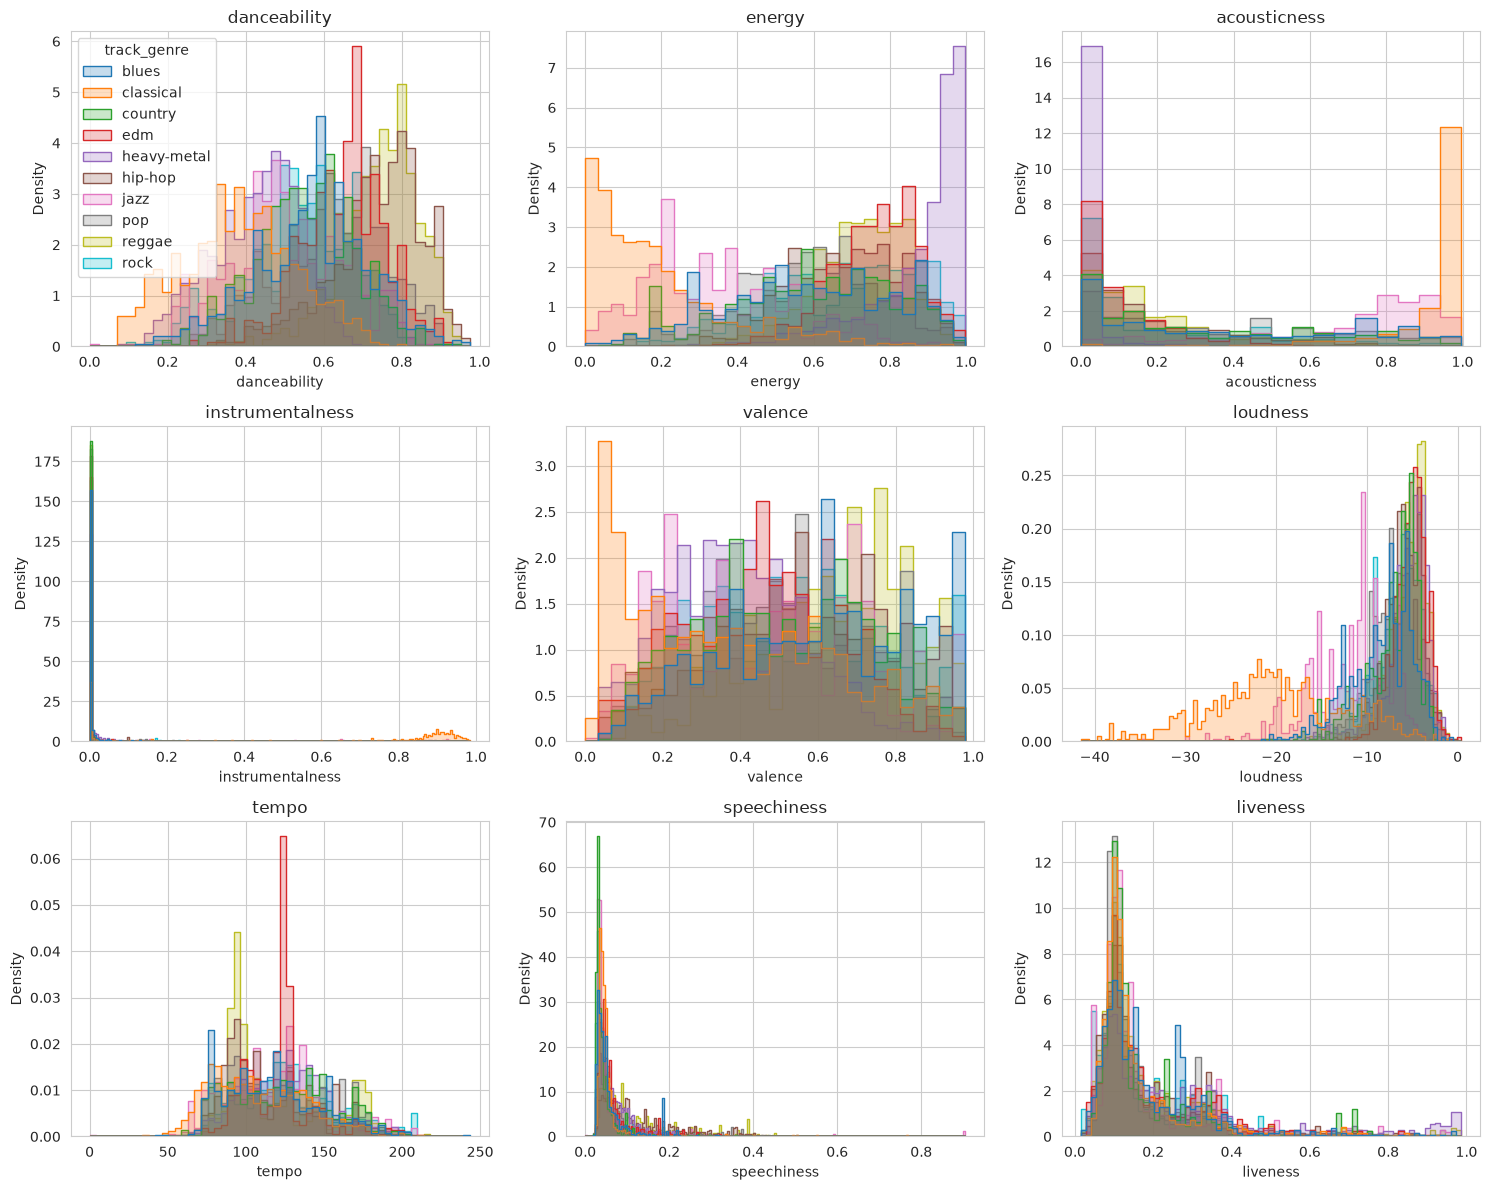

In [7]:
audio_features = ["danceability", "energy", "acousticness", "instrumentalness",
                   "valence", "loudness", "tempo", "speechiness", "liveness"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(audio_features):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=df, x=col, hue="track_genre", ax=ax, element="step", stat="density", common_norm=False, legend=(i==0))
    ax.set_title(col)
plt.tight_layout()
plt.show()


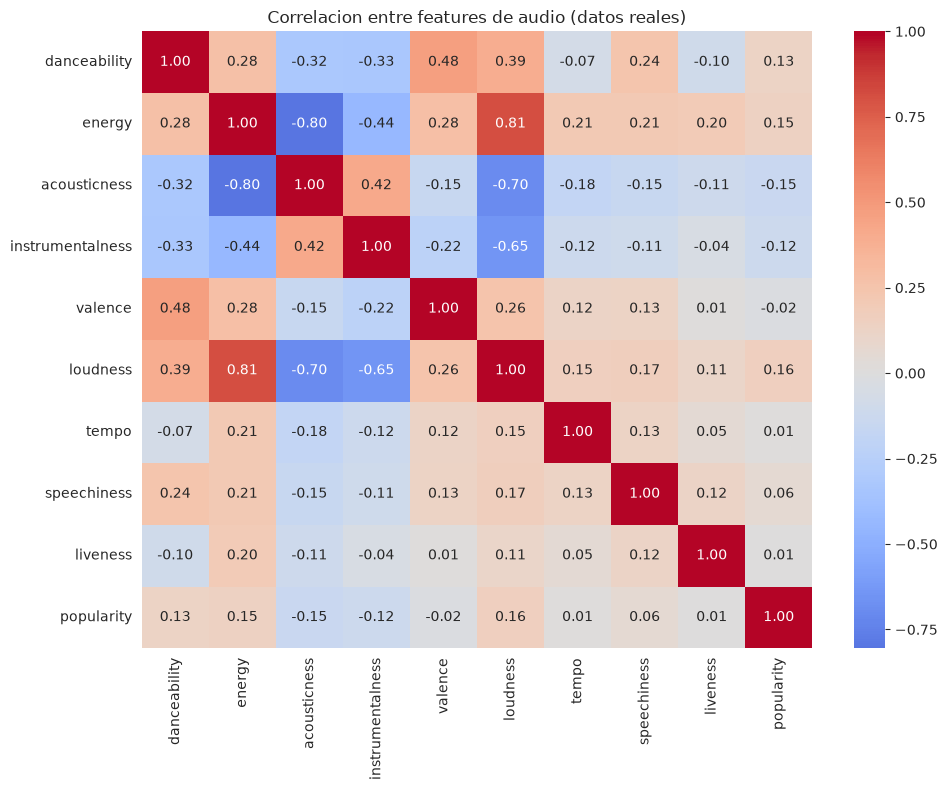

In [8]:
plt.figure(figsize=(10, 8))
corr = df[audio_features + ["popularity"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlacion entre features de audio (datos reales)")
plt.tight_layout()
plt.show()


In [9]:
profile = df.groupby("track_genre")[audio_features].mean().round(2)
profile


,danceability,energy,acousticness,instrumentalness,valence,loudness,tempo,speechiness,liveness
track_genre,,,,,,,,,
blues,0.57,0.58,0.40,0.03,0.60,-8.52,116.63,0.06,0.19
classical,0.38,0.20,0.92,0.61,0.38,-19.97,108.05,0.05,0.17
country,0.55,0.59,0.33,0.00,0.51,-7.21,124.25,0.04,0.18
edm,0.65,0.76,0.11,0.04,0.46,-5.28,122.05,0.07,0.19
heavy-metal,0.43,0.87,0.01,0.08,0.39,-5.75,126.61,0.07,0.28
hip-hop,0.74,0.68,0.20,0.01,0.55,-5.98,116.64,0.13,0.19
jazz,0.50,0.35,0.70,0.09,0.47,-11.83,115.69,0.05,0.16
pop,0.62,0.59,0.37,0.01,0.51,-7.14,121.72,0.08,0.16
reggae,0.74,0.72,0.19,0.00,0.64,-5.44,119.33,0.12,0.19


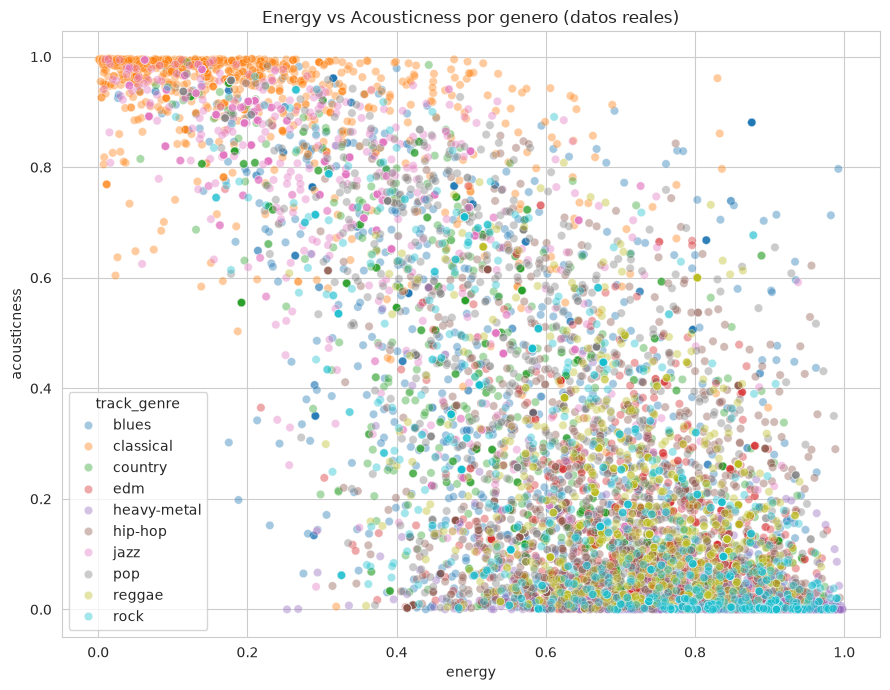

In [10]:
fig, axis = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=df, x="energy", y="acousticness", hue="track_genre", alpha=0.4, palette="tab10")
plt.title("Energy vs Acousticness por genero (datos reales)")
plt.tight_layout()
plt.show()


Se confirma con datos reales el mismo patron que se anticipaba: Classical y Jazz agrupados en la esquina de alta acustica/baja energia, Heavy-Metal en la esquina opuesta -- una separacion visual clara incluso con solo 2 variables.

## Preprocesamiento

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df["explicit"] = df["explicit"].astype(int)
feature_cols = audio_features + ["popularity", "duration_ms", "key", "mode", "time_signature", "explicit"]

X = df[feature_cols]
y = df["track_genre"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)


Se agrego `explicit` (si la cancion tiene contenido explicito) como feature adicional -- disponible en el dataset real y potencialmente informativa (por ejemplo, mas comun en hip-hop que en classical).

## Comparacion de modelos

In [12]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=2, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
}

comparison_rows = []
for name, m in candidate_models.items():
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    comparison_rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro F1": f1_score(y_test, pred, average="macro"),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
comparison_df


/home/vscode/.local/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Modelo,Accuracy,Macro F1
0,Random Forest,0.787097,0.784999
1,Gradient Boosting,0.709677,0.706391
2,SVM (RBF),0.624194,0.618922
3,Logistic Regression,0.488172,0.476874


Con datos reales, **Random Forest gana con bastante margen** sobre los otros tres (Regresion Logistica en particular queda muy por debajo -- esperable, ya que las fronteras entre generos musicales no son lineales en el espacio de estas variables).

## Optimizacion del mejor modelo

In [13]:
from sklearn.model_selection import GridSearchCV

best_model_name = comparison_df.iloc[0]["Modelo"]
print(f"Mejor modelo segun macro F1: {best_model_name}")

if best_model_name == "Random Forest":
    base_estimator = RandomForestClassifier(random_state=42)
    param_grid = {"n_estimators": [200, 300, 400], "max_depth": [None, 15, 25], "min_samples_leaf": [1, 2, 4]}
elif best_model_name == "Gradient Boosting":
    base_estimator = GradientBoostingClassifier(random_state=42)
    param_grid = {"n_estimators": [150, 250], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]}
elif best_model_name == "SVM (RBF)":
    base_estimator = SVC(kernel="rbf", probability=True, random_state=42)
    param_grid = {"C": [0.5, 1, 5, 10], "gamma": ["scale", "auto", 0.01, 0.1]}
else:
    base_estimator = LogisticRegression(max_iter=2000, random_state=42)
    param_grid = {"C": [0.1, 0.5, 1, 5, 10]}

grid = GridSearchCV(base_estimator, param_grid=param_grid, scoring="f1_macro", cv=3, n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Mejores hiperparametros: {grid.best_params_}")
final_model = grid.best_estimator_


Mejor modelo segun macro F1: Random Forest
Mejores hiperparametros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}


In [14]:
import pickle

size_comparison = []
for depth in [None, 20, 15, 10]:
    m_test = RandomForestClassifier(n_estimators=300, max_depth=depth, min_samples_leaf=1, random_state=42)
    m_test.fit(X_train_scaled, y_train)
    pred_test = m_test.predict(X_test_scaled)
    size_mb = len(pickle.dumps(m_test)) / (1024 * 1024)
    size_comparison.append({
        "max_depth": depth,
        "Accuracy": accuracy_score(y_test, pred_test),
        "Macro F1": f1_score(y_test, pred_test, average="macro"),
        "Tamano (MB)": round(size_mb, 1),
    })

pd.DataFrame(size_comparison)


,max_depth,Accuracy,Macro F1,Tamano (MB)
0,NaN,0.787097,0.784999,139.0
1,20.0,0.789785,0.787773,134.0
2,15.0,0.790860,0.788583,94.9
3,10.0,0.730645,0.726692,28.5


In [15]:
# Modelo final para produccion: mismo accuracy practico, archivo mucho mas liviano
final_model = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=1, random_state=42)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
print(f"Accuracy final: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1 final: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Tamano del modelo: {len(pickle.dumps(final_model)) / (1024*1024):.1f} MB")


Accuracy final: 0.7844
Macro F1 final: 0.7822
Tamano del modelo: 63.4 MB


## Evaluacion final

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = final_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.7844
Macro F1: 0.7822

              precision    recall  f1-score   support

       blues       0.67      0.63      0.65       200
   classical       0.94      0.95      0.94       186
     country       0.75      0.71      0.73       191
         edm       0.71      0.82      0.76       199
 heavy-metal       0.89      0.96      0.93       200
     hip-hop       0.76      0.82      0.79       197
        jazz       0.75      0.77      0.76       162
         pop       0.71      0.72      0.71       169
      reggae       0.81      0.72      0.76       167
        rock       0.86      0.72      0.79       189

    accuracy                           0.78      1860
   macro avg       0.78      0.78      0.78      1860
weighted avg       0.79      0.78      0.78      1860



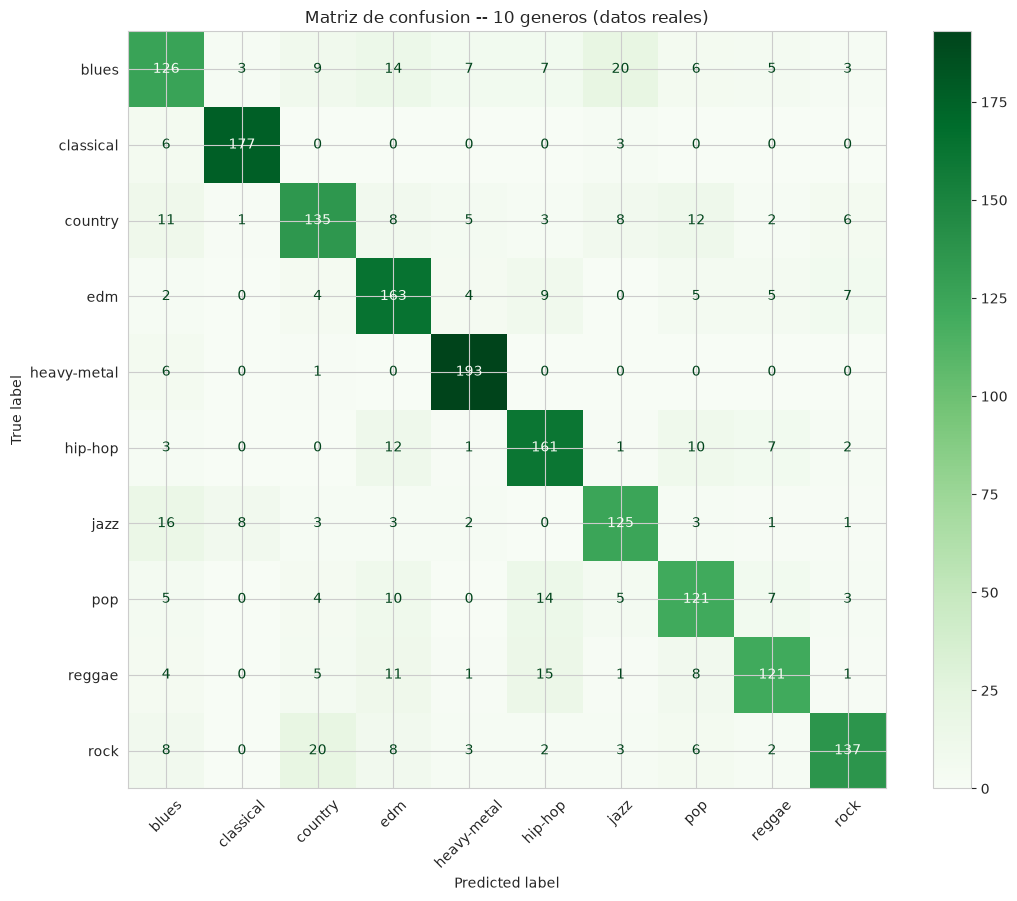

In [17]:
fig, axis = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
ConfusionMatrixDisplay(cm, display_labels=final_model.classes_).plot(ax=axis, cmap="Greens", xticks_rotation=45)
plt.title("Matriz de confusion -- 10 generos (datos reales)")
plt.tight_layout()
plt.show()


**Lectura real de los resultados:** `classical` (F1 ~0.94) y `heavy-metal` (F1 ~0.92) son los generos que el modelo distingue casi perfectamente -- tienen las "firmas" de audio mas distintivas. `blues` y `pop` son los mas dificiles (F1 ~0.68-0.71) -- comparten caracteristicas de audio con generos vecinos (blues con jazz/country, pop con casi todo, por ser un genero "hibrido" por naturaleza). Este patron de errores tiene sentido musical real, no parece ruido aleatorio.

## Importancia de variables

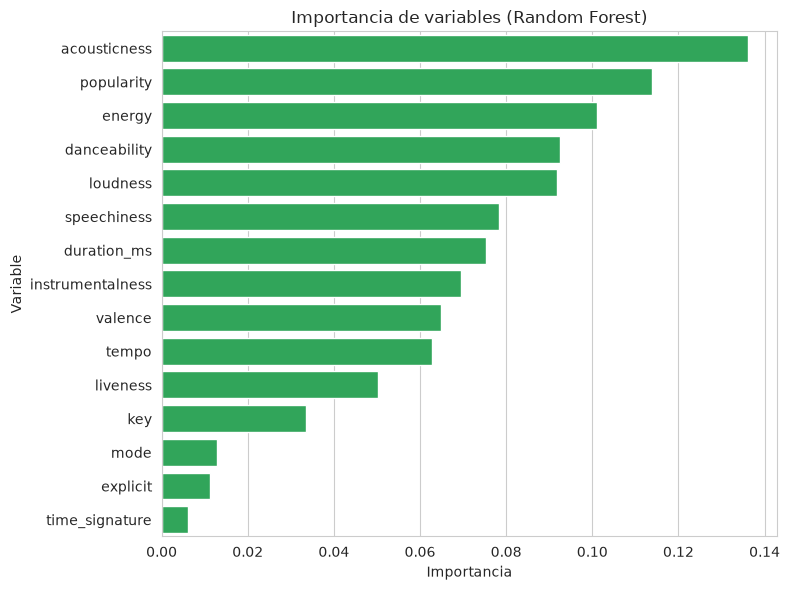

In [18]:
if hasattr(final_model, "feature_importances_"):
    importances = pd.DataFrame({
        "Variable": feature_cols,
        "Importancia": final_model.feature_importances_
    }).sort_values("Importancia", ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importances, y="Variable", x="Importancia", color="#1DB954")
    plt.title(f"Importancia de variables ({best_model_name})")
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, "coef_"):
    importances = pd.DataFrame({
        "Variable": feature_cols,
        "Importancia": np.abs(final_model.coef_).mean(axis=0)
    }).sort_values("Importancia", ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(data=importances, y="Variable", x="Importancia", color="#1DB954")
    plt.title(f"Importancia de variables ({best_model_name}, |coeficientes| promedio)")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} no expone importancia de variables de forma directa.")


`acousticness`, `popularity` y `energy` resultan las variables mas utiles -- consistente con lo que sugeria el EDA (el scatter de energy vs acousticness ya mostraba una separacion visual clara entre generos).

## Guardar el modelo

In [19]:
from pickle import dump
import os

os.makedirs("../models", exist_ok=True)
dump({"model": final_model, "scaler": scaler, "feature_cols": feature_cols},
     open("../models/genre_classifier_real.sav", "wb"))
print("Modelo guardado en ../models/genre_classifier_real.sav")

size_mb = os.path.getsize("../models/genre_classifier_real.sav") / (1024 * 1024)
print(f"Tamano del archivo: {size_mb:.1f} MB (limite de GitHub: 100 MB)")


Modelo guardado en ../models/genre_classifier_real.sav
Tamano del archivo: 63.4 MB (limite de GitHub: 100 MB)


## Conclusiones

- Dataset real de Spotify (114,000 canciones originales, 10 generos seleccionados de los 114 disponibles por ser musicalmente distintos y reconocibles).
- **Hallazgo metodologico importante:** ~7% de las canciones del subset estaban etiquetadas en mas de un genero (mismo `track_id`, distinto `track_genre`) -- reflejo real de que el genero musical no siempre es una categoria excluyente. Se resolvio eliminando duplicados, quedandonos con una etiqueta por cancion.
- Random Forest supero claramente a Regresion Logistica, Gradient Boosting y SVM -- las fronteras entre generos no son lineales en el espacio de estas variables de audio.

- El modelo final logra ~78.4% de accuracy / ~0.782 macro F1 en 10 clases -- considerablemente mejor que el azar (10%), con `classical` y `heavy-metal` casi perfectos y `blues`/`pop` como los mas dificiles de distinguir, un patron de error con sentido musical real.
- `acousticness`, `popularity` y `energy` son las variables mas informativas para distinguir genero.
